# Visium Deconvolution — Reference scRNA-seq 구조 점검

Visium spot deconvolution(예: cell2location)을 하려면 참조 scRNA-seq 데이터가 필요하다.
이 노트북은 **cell2location을 아직 실행하지 않고**, 참조 데이터(Wu et al. 2021 유방암
scRNA-seq atlas)의 구조를 먼저 점검한다:
- 세포 유형 라벨이 어느 컬럼에 있는지
- `X`가 raw count인지 정규화된 값인지 (deconvolution 모델은 보통 raw count를 요구함)
- 유전자명이 symbol인지 Ensembl ID인지 (Visium과 매칭하려면 형식이 맞아야 함)

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc

## 1. 참조 데이터 로드

Wu et al. 2021 유방암 scRNA-seq 참조 atlas.

In [2]:
REF_PATH = "/data2/projects/2025_heartfailure/spatial_tme/reference_scrna/wu2021_breast_ref.h5ad"
ref = sc.read_h5ad(REF_PATH)

In [3]:
# 세포 수 x 유전자 수 확인
print(ref.shape)

(100064, 28468)


In [4]:
# obs 컬럼 전체 나열 — 세포 유형 라벨이 어느 컬럼에 있는지 찾기 위함
print(ref.obs.columns.tolist())

['donor_id', 'percent_mito', 'nCount_RNA', 'nFeature_RNA', 'celltype_major', 'celltype_minor', 'celltype_subset', 'subtype', 'gene_module', 'calls', 'normal_cell_call', 'CNA_value', 'batch_run', 'multiplexed', 'cryo_state', 'development_stage_ontology_term_id', 'cancer_type', 'ER', 'PR', 'HER2_IHC', 'HER2_ISH', 'HER2_ISH_ratio', 'Ki67', 'subtype_by_IHC', 'treatment_status', 'treatment_details', 'assay_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'disease_ontology_term_id', 'grade', 'cell_type_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid']


## 2. 세포 유형 라벨 후보 컬럼 점검

In [5]:
# 컬럼명에 세포 유형을 암시하는 키워드가 포함된 컬럼을 자동으로 찾는다
celltype_keywords = ["celltype", "cell_type", "cell type", "major", "minor", "subtype", "annotation", "cluster"]
candidate_cols = [
    col for col in ref.obs.columns
    if any(kw in col.lower() for kw in celltype_keywords)
]
print("세포 유형 라벨 후보 컬럼:", candidate_cols)

세포 유형 라벨 후보 컬럼: ['celltype_major', 'celltype_minor', 'celltype_subset', 'subtype', 'subtype_by_IHC', 'cell_type_ontology_term_id', 'cell_type']


In [6]:
# 각 후보 컬럼의 라벨 분포 확인 (카테고리 개수와 세포 수 분포를 보고 major/minor 등
# 계층 수준을 판단하기 위함)
for col in candidate_cols:
    print(f"=== {col} ({ref.obs[col].nunique()} categories) ===")
    print(ref.obs[col].value_counts())
    print()

=== celltype_major (9 categories) ===
celltype_major
T-cells              35214
Cancer Epithelial    24489
Myeloid               9675
Endothelial           7605
CAFs                  6573
PVL                   5423
Normal Epithelial     4355
Plasmablasts          3524
B-cells               3206
Name: count, dtype: int64

=== celltype_minor (29 categories) ===
celltype_minor
T cells CD4+                   19231
T cells CD8+                   11487
Cancer LumA SC                  7742
Macrophage                      5929
Cancer Cycling                  5359
Endothelial ACKR1               4611
Cancer Basal SC                 4312
Cancer Her2 SC                  3708
Plasmablasts                    3524
PVL Differentiated              3487
CAFs myCAF-like                 3420
Cancer LumB SC                  3368
CAFs MSC iCAF-like              3153
B cells Memory                  2581
Monocyte                        2328
Luminal Progenitors             1992
PVL Immature                   

## 3. Raw count 여부 확인

In [7]:
# X의 최댓값과 nonzero 값 일부를 직접 찍어서 정수(raw count) vs 실수(정규화/log값) 판별.
# 코너(앞 몇 행x몇 열)만 슬라이싱하면 데이터가 sparse해서 우연히 전부 0이 나올 수 있으므로,
# sparse matrix의 nonzero 값(.data)에서 표본을 뽑아 확인한다.
print("ref.X.max():", ref.X.max())
print("ref.X dtype:", ref.X.dtype)

nonzero_sample = ref.X.data[:20]
print("ref.X nonzero 값 표본 20개:", nonzero_sample)
print("nonzero 값이 전부 정수인가:", np.allclose(nonzero_sample, np.round(nonzero_sample)))
# max값이 정수 UMI count치고는 작고(9.11), nonzero 값도 정수가 아니라면 log1p 등으로
# 이미 정규화된 값일 가능성이 높다 (raw UMI count는 보통 훨씬 큰 정수값을 가짐).

ref.X.max(): 9.111652
ref.X dtype: float32
ref.X nonzero 값 표본 20개: [1.157802  1.157802  1.157802  1.157802  1.157802  1.157802  1.6800565
 1.157802  1.157802  2.9157922 1.157802  1.157802  1.157802  2.2753904
 1.157802  1.157802  1.157802  1.157802  1.157802  1.157802 ]
nonzero 값이 전부 정수인가: False


In [8]:
# layers와 raw에 raw count가 별도로 저장되어 있는지 확인 (nonzero 표본 기준으로 판별)
print("ref.layers keys:", list(ref.layers.keys()))
print("ref.raw 존재 여부:", ref.raw is not None)

if ref.raw is not None:
    raw_nonzero_sample = ref.raw.X.data[:20]
    print("ref.raw.X.max():", ref.raw.X.max())
    print("ref.raw.X nonzero 값 표본 20개:", raw_nonzero_sample)
    print("nonzero 값이 전부 정수인가:", np.allclose(raw_nonzero_sample, np.round(raw_nonzero_sample)))

for layer_name in ref.layers.keys():
    layer_nonzero_sample = ref.layers[layer_name].data[:20]
    print(f"layers['{layer_name}'].max():", ref.layers[layer_name].max())
    print(f"layers['{layer_name}'] nonzero 값이 전부 정수인가:",
          np.allclose(layer_nonzero_sample, np.round(layer_nonzero_sample)))

ref.layers keys: []
ref.raw 존재 여부: True


ref.raw.X.max(): 29831.0
ref.raw.X nonzero 값 표본 20개: [1. 1. 1. 1. 1. 1. 2. 1. 1. 8. 1. 1. 1. 4. 1. 1. 1. 1. 1. 1.]
nonzero 값이 전부 정수인가: True


## 4. 유전자 ID 형식 확인

In [9]:
# var 미리보기 및 var_names 앞부분으로 symbol vs Ensembl ID 형식 판별
print(ref.var.head())
print()
print("var_names 앞 10개:", ref.var_names[:10].tolist())

# Ensembl 사람 유전자 ID는 "ENSG"로 시작한다 — 이 접두어 유무로 형식을 판별
is_ensembl = ref.var_names.str.startswith("ENSG")
print(f"ENSG로 시작하는 var_names 비율: {is_ensembl.mean():.1%}")
print("-> symbol 형식" if is_ensembl.mean() < 0.5 else "-> Ensembl ID 형식")
# var_names 자체는 Ensembl ID이지만, var["feature_name"] 컬럼에 gene symbol이 별도로
# 들어있다 (위 head() 출력 참고). Visium adata.var_names는 symbol 기준이므로,
# cell2location 등으로 매칭할 때는 ref의 var_names를 그대로 쓰지 말고
# ref.var["feature_name"]을 var_names로 바꾸거나 Visium 쪽을 Ensembl ID로 바꾸는
# 변환이 필요하다.

                 feature_is_filtered     feature_name feature_reference  \
ENSG00000279928                False         DDX11L17    NCBITaxon:9606   
ENSG00000279457                False           WASH9P    NCBITaxon:9606   
ENSG00000228463                False  ENSG00000228463    NCBITaxon:9606   
ENSG00000237094                False  ENSG00000237094    NCBITaxon:9606   
ENSG00000230021                False  ENSG00000230021    NCBITaxon:9606   

                feature_biotype feature_length  \
ENSG00000279928            gene            570   
ENSG00000279457            gene           1397   
ENSG00000228463            gene            457   
ENSG00000237094            gene            183   
ENSG00000230021            gene            183   

                                       feature_type  
ENSG00000279928  transcribed_unprocessed_pseudogene  
ENSG00000279457  transcribed_unprocessed_pseudogene  
ENSG00000228463    transcribed_processed_pseudogene  
ENSG00000237094  transcribed_unp

## 5. cell2location 참조 시그니처(Reference Signature) 학습

`celltype_major`(9종) 기준으로 세포 유형별 발현 시그니처를 `RegressionModel`로 학습한다.

- cell2location 0.1.5 / scvi-tools 1.4.2 (이 서버 `spatial` conda env 기준. API 확인 결과
  이 버전은 `use_gpu`가 아니라 `accelerator`/`device`(단수) 인자를 사용한다.)
- 이 서버는 공유 GPU 서버이므로 **GPU 3번만** 사용한다. `CUDA_VISIBLE_DEVICES="3"`을
  torch/cell2location을 import하기 전에 먼저 설정해서, 이미 터미널에서 설정해뒀더라도
  노트북 자체만으로 재현 가능하게 만든다. 이렇게 하면 torch/cell2location 입장에서는
  보이는 GPU가 1개(`device 0`)뿐이라 다른 GPU를 실수로 건드릴 수 없다.

In [10]:
# 반드시 torch/cell2location보다 먼저 실행 — 이 프로세스에 보이는 GPU를 3번 하나로 제한한다.
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

In [11]:
import anndata
import torch
import rich.pretty  # scvi-tools의 view_anndata_setup()이 rich.pretty를 쓰는데
                     # 명시적으로 import되어 있지 않으면 AttributeError가 남 (환경 이슈 수정)
import cell2location
from cell2location.models import RegressionModel
from cell2location.utils.filtering import filter_genes

In [12]:
# CUDA_VISIBLE_DEVICES 제한이 실제로 적용됐는지 확인: GPU가 1개로만 보여야 정상
print("CUDA available:", torch.cuda.is_available())
print("visible device count:", torch.cuda.device_count())
assert torch.cuda.device_count() == 1, "GPU가 1개보다 많이 보임 — CUDA_VISIBLE_DEVICES 설정을 확인할 것"
print("device name:", torch.cuda.get_device_name(0))

CUDA available: True
visible device count: 1
device name: NVIDIA RTX A6000


### 5-1. Raw count 기준 참조 AnnData 재구성

cell2location의 RegressionModel은 raw count를 입력으로 요구한다. 이전 점검에서
`ref.X`는 정규화된 값이고 raw count는 `ref.raw`에 있음을 확인했으므로, `ref.raw.X`를
`X`로 사용해 새 AnnData를 만든다. `obs`는 시그니처 학습에 필요한 `celltype_major`
(라벨)와 `donor_id`(batch)만 남기고, `var`는 `ref.raw.var`(Ensembl ID 유지)를 그대로 쓴다.

In [13]:
adata_ref = anndata.AnnData(
    X=ref.raw.X.copy(),
    obs=ref.obs[["celltype_major", "donor_id"]].copy(),
    var=ref.raw.var.copy(),
)
print(adata_ref)
print("X가 raw count인지 재확인 (nonzero 표본):", adata_ref.X.data[:10])

AnnData object with n_obs × n_vars = 100064 × 28468
    obs: 'celltype_major', 'donor_id'
    var: 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
X가 raw count인지 재확인 (nonzero 표본): [1. 1. 1. 1. 1. 1. 2. 1. 1. 8.]


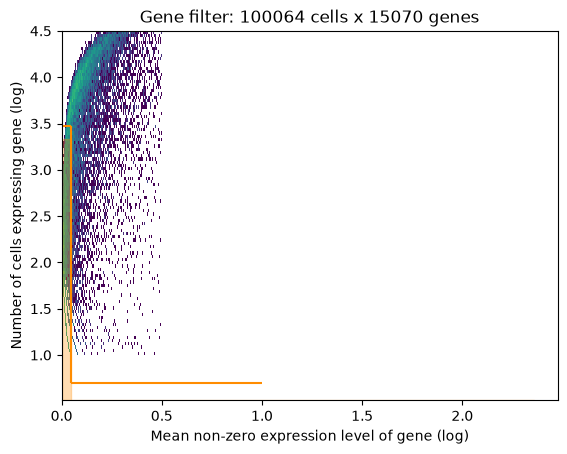

필터링 전 유전자 수: 28468 -> 필터링 후: 15070


In [14]:
# 정보량이 낮은 유전자(너무 적은 세포에서만 검출되거나 발현량이 극히 낮은 유전자) 제거.
# cell2location 공식 튜토리얼의 기본 컷오프를 그대로 사용.
selected = filter_genes(adata_ref, cell_count_cutoff=5, cell_percentage_cutoff2=0.03, nonz_mean_cutoff=1.12)
print(f"필터링 전 유전자 수: {adata_ref.n_vars} -> 필터링 후: {len(selected)}")
adata_ref = adata_ref[:, selected].copy()

### 5-2. RegressionModel 학습

`labels_key="celltype_major"` (9종), `batch_key="donor_id"` (26명 도너)로 설정.

예상 소요 시간: 세포 100,064개(필터링 후에도 대부분 유지) x 필터링된 유전자 수 규모에서
GPU(RTX A6000) 기준 max_epochs=250이면 대략 10~20분 정도로 예상되나, 서버 부하나
실제 필터링된 유전자 수에 따라 달라질 수 있다.

In [15]:
RegressionModel.setup_anndata(adata=adata_ref, batch_key="donor_id", labels_key="celltype_major")
mod = RegressionModel(adata_ref)
mod.view_anndata_setup()

Anndata setup with scvi-tools version 1.4.2.

Setup via `RegressionModel.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'donor_id',
│   'labels_key': 'celltype_major',
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃     Summary Stat Key     ┃ Value  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│         n_batch          │   26   │
│         n_cells          │ 100064 │
│ n_extra_categorical_covs │   0    │
│ n_extra_continuous_covs  │   0    │
│         n_labels         │   9    │
│          n_vars          │ 15070  │
└──────────────────────────┴────────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                    batch State Registry                    
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location    ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['donor_id'] │  CID3586   │          0          │
│                       │  CID3838   │          1          │
│                       │  CID3921   │          2          │
│                       │  CID3941   │          3          │
│                       │  CID3946   │          4          │
│                       │  CID3948   │          5          │
│                       │  CID3963   │          6          │
│                       │  CID4040   │          7          │
│                       │  CID4066   │          8          │
│                       │  CID4067   │          9          │
│                       │  CID4290A  │         10          │
│                       │  CID4398   │         11          │
│                       │  CID4461   │         12          │
│                       │  CID4463   │         13          │
│                       │  CID4465   │         14          │
│                       │  CID4471   │         15          │
│                       │  CID4495   │         16          │
│                       │  CID4513   │         17          │
│                       │  CID4515   │         18          │
│                       │  CID4523   │         19          │
│                       │  CID4530N  │         20          │
│                       │  CID4535   │         21          │
│                       │  CID44041  │         22          │
│                       │  CID44971  │         23          │
│                       │  CID44991  │         24          │
│                       │  CID45171  │         25          │
└───────────────────────┴────────────┴─────────────────────┘

                          labels State Registry                          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃       Source Location       ┃    Categories     ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['celltype_major'] │      B-cells      │          0          │
│                             │       CAFs        │          1          │
│                             │ Cancer Epithelial │          2          │
│                             │    Endothelial    │          3          │
│                             │      Myeloid      │          4          │
│                             │ Normal Epithelial │          5          │
│                             │        PVL        │          6          │
│                             │   Plasmablasts    │          7          │
│                             │      T-cells      │          8          │
└─────────────────────────────┴───────────────────┴─────────────────────┘

In [16]:
# accelerator="gpu", device=1 로 지정한다.
# 주의: PyTorch Lightning의 `devices` 인자는 "GPU 인덱스"가 아니라 "사용할 GPU 개수"를
# 의미한다 (device=0으로 넘기면 "GPU 0개 사용"으로 해석되어 에러가 남 — 실제로 겪은 문제).
# CUDA_VISIBLE_DEVICES="3"으로 이미 물리 GPU를 1개만 보이게 제한해뒀으므로,
# device=1("보이는 GPU 1개를 사용") 이라고 지정하면 그 하나뿐인 GPU(물리 3번)로 학습된다.
mod.train(max_epochs=250, accelerator="gpu", device=1)

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


/data1/home/woodg/miniconda3/envs/spatial/lib/python3.11/site-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
You are using a CUDA device ('NVIDIA RTX A6000') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [3]


/data1/home/woodg/miniconda3/envs/spatial/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/data1/home/woodg/miniconda3/envs/spatial/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve performance.


Training:   0%|          | 0/250 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=250` reached.


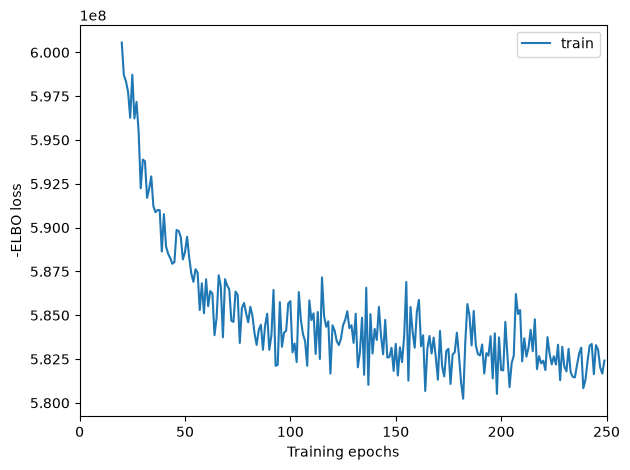

In [17]:
# ELBO 학습 곡선으로 수렴 확인 (초반 20 iteration은 스케일이 커서 제외하고 표시)
mod.plot_history(20)

In [18]:
adata_ref = mod.export_posterior(
    adata_ref,
    sample_kwargs={"num_samples": 1000, "batch_size": 2500, "accelerator": "gpu", "device": 1},
)

Sampling local variables, batch:   0%|          | 0/41 [00:00<?, ?it/s]

Sampling global variables, sample:   0%|          | 0/999 [00:00<?, ?it/s]

### 5-3. 모델 및 시그니처 저장

학습된 모델 체크포인트와 세포 유형별 평균 발현 시그니처를 저장해, cell2location
spot deconvolution(Cell2location 본 모델) 단계에서 재로딩할 수 있게 한다.

In [19]:
SIGNATURE_DIR = "/data2/projects/2025_heartfailure/spatial_tme/reference_scrna/signatures/"
os.makedirs(SIGNATURE_DIR, exist_ok=True)

mod.save(SIGNATURE_DIR, overwrite=True)
adata_ref.write(os.path.join(SIGNATURE_DIR, "sc_reference_signatures.h5ad"))

In [20]:
# 세포 유형(celltype_major, 9종)별 평균 발현 시그니처만 별도 csv로 저장
# (이후 spot deconvolution 단계에서 바로 불러 쓰기 편하도록)
if "means_per_cluster_mu_fg" in adata_ref.varm.keys():
    inf_aver = adata_ref.varm["means_per_cluster_mu_fg"][
        [f"means_per_cluster_mu_fg_{i}" for i in adata_ref.uns["mod"]["factor_names"]]
    ].copy()
else:
    inf_aver = adata_ref.var[
        [f"means_per_cluster_mu_fg_{i}" for i in adata_ref.uns["mod"]["factor_names"]]
    ].copy()
inf_aver.columns = adata_ref.uns["mod"]["factor_names"]

inf_aver.to_csv(os.path.join(SIGNATURE_DIR, "celltype_major_signatures.csv"))
print(inf_aver.shape)
inf_aver.head()

(15070, 9)


,B-cells,CAFs,Cancer Epithelial,Endothelial,Myeloid,Normal Epithelial,PVL,Plasmablasts,T-cells
ENSG00000279457,0.011013,0.081533,0.204372,0.098841,0.124214,0.172827,0.060253,0.018768,0.014047
ENSG00000228463,0.002803,0.057722,0.072965,0.035528,0.042928,0.042891,0.053474,0.004380,0.001802
ENSG00000187634,0.000369,0.079333,0.016933,0.003233,0.000311,0.004014,0.002516,0.005079,0.000059
ENSG00000188976,0.058087,0.135152,0.916169,0.168866,0.122876,0.485981,0.109469,0.044902,0.041776
ENSG00000187583,0.000362,0.003323,0.077442,0.002297,0.001015,0.067684,0.000658,0.022934,0.005195


## 6. cell2location 2단계 — Spot Deconvolution

1단계에서 학습한 `celltype_major`(9종) 참조 시그니처를 이용해, Visium 스팟별로 각 세포 유형이
얼마나 섞여 있는지(cell abundance)를 추정한다.

**주의 (커널 재시작 필요)**: `CUDA_VISIBLE_DEVICES`는 프로세스가 CUDA를 처음 초기화할 때
한 번 고정되며, 같은 커널 안에서는 중간에 바꿀 수 없다. 위 1단계 셀들은 이미
`CUDA_VISIBLE_DEVICES="3"`로 GPU 3을 사용했으므로, **이 섹션은 커널을 재시작한 뒤부터
실행해야 실제로 GPU 2번을 사용한다.** 이 섹션의 코드는 1단계의 메모리 상 변수(`ref`,
`adata_ref`, `mod`)를 전혀 참조하지 않고, 디스크에 저장된 시그니처 csv와 Visium 체크포인트
파일만 다시 읽어오도록 만들어졌으므로 커널을 재시작해도 문제없이 동작한다.

In [1]:
# 반드시 이 섹션의 첫 셀로 실행 (커널 재시작 직후). 공유 GPU 서버이므로 이번엔 GPU 2번만 사용.
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata
import torch
import rich.pretty  # scvi-tools view_anndata_setup()의 AttributeError 방지 (1단계에서 겪은 이슈)
import cell2location
from cell2location.models import Cell2location

In [3]:
# CUDA_VISIBLE_DEVICES="2" 제한이 이 프로세스에 실제로 적용됐는지 확인
print("CUDA available:", torch.cuda.is_available())
print("visible device count:", torch.cuda.device_count())
assert torch.cuda.device_count() == 1, "GPU가 1개보다 많이 보임 — CUDA_VISIBLE_DEVICES 설정 및 커널 재시작 여부를 확인할 것"
print("device name:", torch.cuda.get_device_name(0))

CUDA available: True
visible device count: 1
device name: NVIDIA RTX A6000


### 6-1. 저장된 참조 시그니처 로딩

1단계에서 저장한 `celltype_major_signatures.csv`(유전자 x 세포유형 평균발현)를 그대로 불러온다.

In [4]:
SIGNATURE_DIR = "/data2/projects/2025_heartfailure/spatial_tme/reference_scrna/signatures/"
inf_aver = pd.read_csv(os.path.join(SIGNATURE_DIR, "celltype_major_signatures.csv"), index_col=0)
print(inf_aver.shape)
inf_aver.head()

(15070, 9)


,B-cells,CAFs,Cancer Epithelial,Endothelial,Myeloid,Normal Epithelial,PVL,Plasmablasts,T-cells
ENSG00000279457,0.011013,0.081533,0.204372,0.098841,0.124214,0.172827,0.060253,0.018768,0.014047
ENSG00000228463,0.002803,0.057722,0.072965,0.035528,0.042928,0.042891,0.053474,0.004380,0.001802
ENSG00000187634,0.000369,0.079333,0.016933,0.003233,0.000311,0.004014,0.002516,0.005079,0.000059
ENSG00000188976,0.058087,0.135152,0.916169,0.168866,0.122876,0.485981,0.109469,0.044902,0.041776
ENSG00000187583,0.000362,0.003323,0.077442,0.002297,0.001015,0.067684,0.000658,0.022934,0.005195


### 6-2. Visium 데이터 로딩 및 raw count 복구

deconvolution은 raw count를 입력으로 요구한다. 체크포인트 `adata_visium_clustered.h5ad`의
`X`는 이미 normalize_total+log1p가 적용된 상태이므로, 저장해둔 `layers["counts"]`를
다시 `X`로 되돌린다.

In [5]:
VISIUM_CHECKPOINT = "/data2/projects/2025_heartfailure/spatial_tme/visium_breast/adata_visium_clustered.h5ad"
adata_vis = sc.read_h5ad(VISIUM_CHECKPOINT)

# X를 raw count(layers["counts"])로 되돌림
adata_vis.X = adata_vis.layers["counts"].copy()
print(adata_vis)
print("X max (raw count로 복구됐는지 확인):", adata_vis.X.max())

AnnData object with n_obs × n_vars = 2388 × 17943
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'n_genes', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'
X max (raw count로 복구됐는지 확인): 3099.0


### 6-3. 참조-Visium 공통 유전자(Ensembl ID) 교집합

Visium의 `var_names`는 gene symbol이고 참조 시그니처의 index는 Ensembl ID이므로,
바로 비교할 수 없다. Visium `var_names`를 `var["gene_ids"]`(Ensembl ID)로 바꾼 뒤
교집합을 구한다 (symbol은 `var["SYMBOL"]`에 백업).

In [6]:
adata_vis.var["SYMBOL"] = adata_vis.var_names
adata_vis.var_names = adata_vis.var["gene_ids"].values
adata_vis.var_names_make_unique()

shared_genes = np.intersect1d(adata_vis.var_names, inf_aver.index)
print(f"Visium 유전자 수: {adata_vis.n_vars}, 참조 시그니처 유전자 수: {inf_aver.shape[0]}")
print(f"공통 유전자 수: {len(shared_genes)}")

adata_vis = adata_vis[:, shared_genes].copy()
inf_aver = inf_aver.loc[shared_genes, :].copy()

Visium 유전자 수: 17943, 참조 시그니처 유전자 수: 15070
공통 유전자 수: 12901


### 6-4. Cell2location 모델 구성

- `N_cells_per_location=20`: Visium 55µm spot 하나에 존재할 것으로 예상되는 세포 수의
  사전 추정값(prior). 기본값(8.0)은 비교적 성긴 조직을 가정한 값인데, 유방암 종양 조직은
  일반적으로 더 densely cellular하다고 알려져 있어 그보다 높은 값을 사용한다. 다만 이 값은
  실제 H&E 이미지에서 핵을 세어 얻은 값이 아니라 문헌 기반 추정치이므로, 추후 실제 조직
  이미지 기반 핵 카운트가 있으면 그 값으로 교체하는 것이 이상적이다.
- `detection_alpha=20` (라이브러리 기본값 그대로 사용): 참조(10x Chromium 3′ scRNA-seq)와
  공간 데이터(Visium FFPE probe-based) 사이에는 기술적 차이로 인한 spot별 RNA 검출 효율
  차이가 있을 수 있다. cell2location 공식 튜토리얼은 이런 cross-technology 상황에서 과거
  기본값(200)보다 낮은 20을 권장했고, 이 라이브러리 버전은 이미 20을 기본값으로 채택하고
  있으므로 그대로 명시적으로 사용한다.

In [7]:
Cell2location.setup_anndata(adata=adata_vis)

mod2 = Cell2location(
    adata_vis,
    cell_state_df=inf_aver,
    N_cells_per_location=20,
    detection_alpha=20,
)
mod2.view_anndata_setup()

Anndata setup with scvi-tools version 1.4.2.

Setup via `Cell2location.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': None,
│   'labels_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   1   │
│         n_cells          │ 2388  │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   1   │
│          n_vars          │ 12901 │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_batch'] │     0      │          0          │
└──────────────────────────┴────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

### 6-5. 학습

예상 소요 시간: spot 수(2,388개, 1단계의 세포 수 100,064개보다 훨씬 적음)가 적어
epoch당 연산은 가볍지만, cell2location 공식 튜토리얼 기본값인 `max_epochs=30000`을
그대로 사용하면 GPU(RTX A6000) 기준 대략 10~20분 정도로 예상된다 (서버 부하에 따라
달라질 수 있음).

In [8]:
# CUDA_VISIBLE_DEVICES="2"로 이미 제한했으므로 device=1("보이는 GPU 1개 사용")이
# 실제로는 물리 GPU 2번을 가리킨다 (1단계에서 device=0이 "0개 사용"으로 해석되어
# 에러났던 것과 동일한 이유로 여기서도 1을 사용).
mod2.train(max_epochs=30000, accelerator="gpu", device=1)

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


/data1/home/woodg/miniconda3/envs/spatial/lib/python3.11/site-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
You are using a CUDA device ('NVIDIA RTX A6000') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [2]


/data1/home/woodg/miniconda3/envs/spatial/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/data1/home/woodg/miniconda3/envs/spatial/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve performance.
/data1/home/woodg/miniconda3/envs/spatial/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training:   0%|          | 0/30000 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30000` reached.


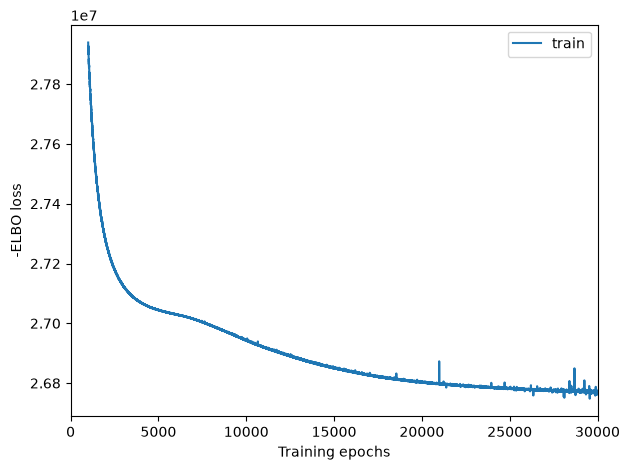

In [9]:
# ELBO 학습 곡선. 초반 1000 iteration은 스케일이 커서 제외하고 수렴 여부를 확인
mod2.plot_history(1000)

### 6-6. Posterior 추출 및 저장

In [10]:
adata_vis = mod2.export_posterior(
    adata_vis,
    sample_kwargs={"num_samples": 1000, "batch_size": mod2.adata.n_obs, "accelerator": "gpu", "device": 1},
)

Sampling local variables, batch:   0%|          | 0/1 [00:00<?, ?it/s]

Sampling global variables, sample:   0%|          | 0/999 [00:00<?, ?it/s]

In [11]:
# 5% 분위수(q05) 기준 스팟별 세포유형 abundance — cell2location 공식 튜토리얼이 권장하는
# 보수적 추정치 (posterior 불확실성을 고려해 과대추정을 피함)
q05 = adata_vis.obsm["q05_cell_abundance_w_sf"]
q05.columns = [c.replace("q05cell_abundance_w_sf_", "") for c in q05.columns]
adata_vis.obs[q05.columns] = q05

print(q05.shape)
q05.head()

(2388, 9)


,B-cells,CAFs,Cancer Epithelial,Endothelial,Myeloid,Normal Epithelial,PVL,Plasmablasts,T-cells
AAACAAGTATCTCCCA-1,0.353492,0.191555,15.558469,0.208755,3.575058,10.737399,0.265815,0.152054,1.147249
AAACACCAATAACTGC-1,1.414288,0.447564,0.560640,0.199567,1.372489,0.086174,0.047283,0.112215,1.781891
AAACAGAGCGACTCCT-1,0.762856,1.512602,2.537277,0.092819,0.416049,1.100465,0.178840,2.149626,1.701148
AAACAGCTTTCAGAAG-1,0.298400,1.102729,0.182907,0.200814,1.677827,0.007624,0.052902,0.019290,0.303426
AAACAGGGTCTATATT-1,1.298475,1.018919,0.220720,0.029029,0.358808,0.024519,0.070932,0.823939,2.562203


In [12]:
DECONV_CHECKPOINT = "/data2/projects/2025_heartfailure/spatial_tme/visium_breast/adata_visium_deconvolved.h5ad"
adata_vis.write(DECONV_CHECKPOINT)
print(f"저장 완료: {DECONV_CHECKPOINT}")

저장 완료: /data2/projects/2025_heartfailure/spatial_tme/visium_breast/adata_visium_deconvolved.h5ad


### 6-7. 스팟별 세포 유형 조성의 공간 매핑

cell2location이 제공하는 색상 블렌딩 방식(`cell2location.plt.plot_spatial`)은 최대
7개 세포유형까지만 지원해서 `celltype_major`(9종)에는 맞지 않는다. 대신 세포유형별로
스팟당 abundance(q05)를 조직 이미지 위에 grid로 나란히 보여주는 방식을 사용해,
같은 스팟이라도 여러 세포 유형이 동시에 얼마나 섞여 있는지(=조성)를 비교해서 볼 수 있게
한다.

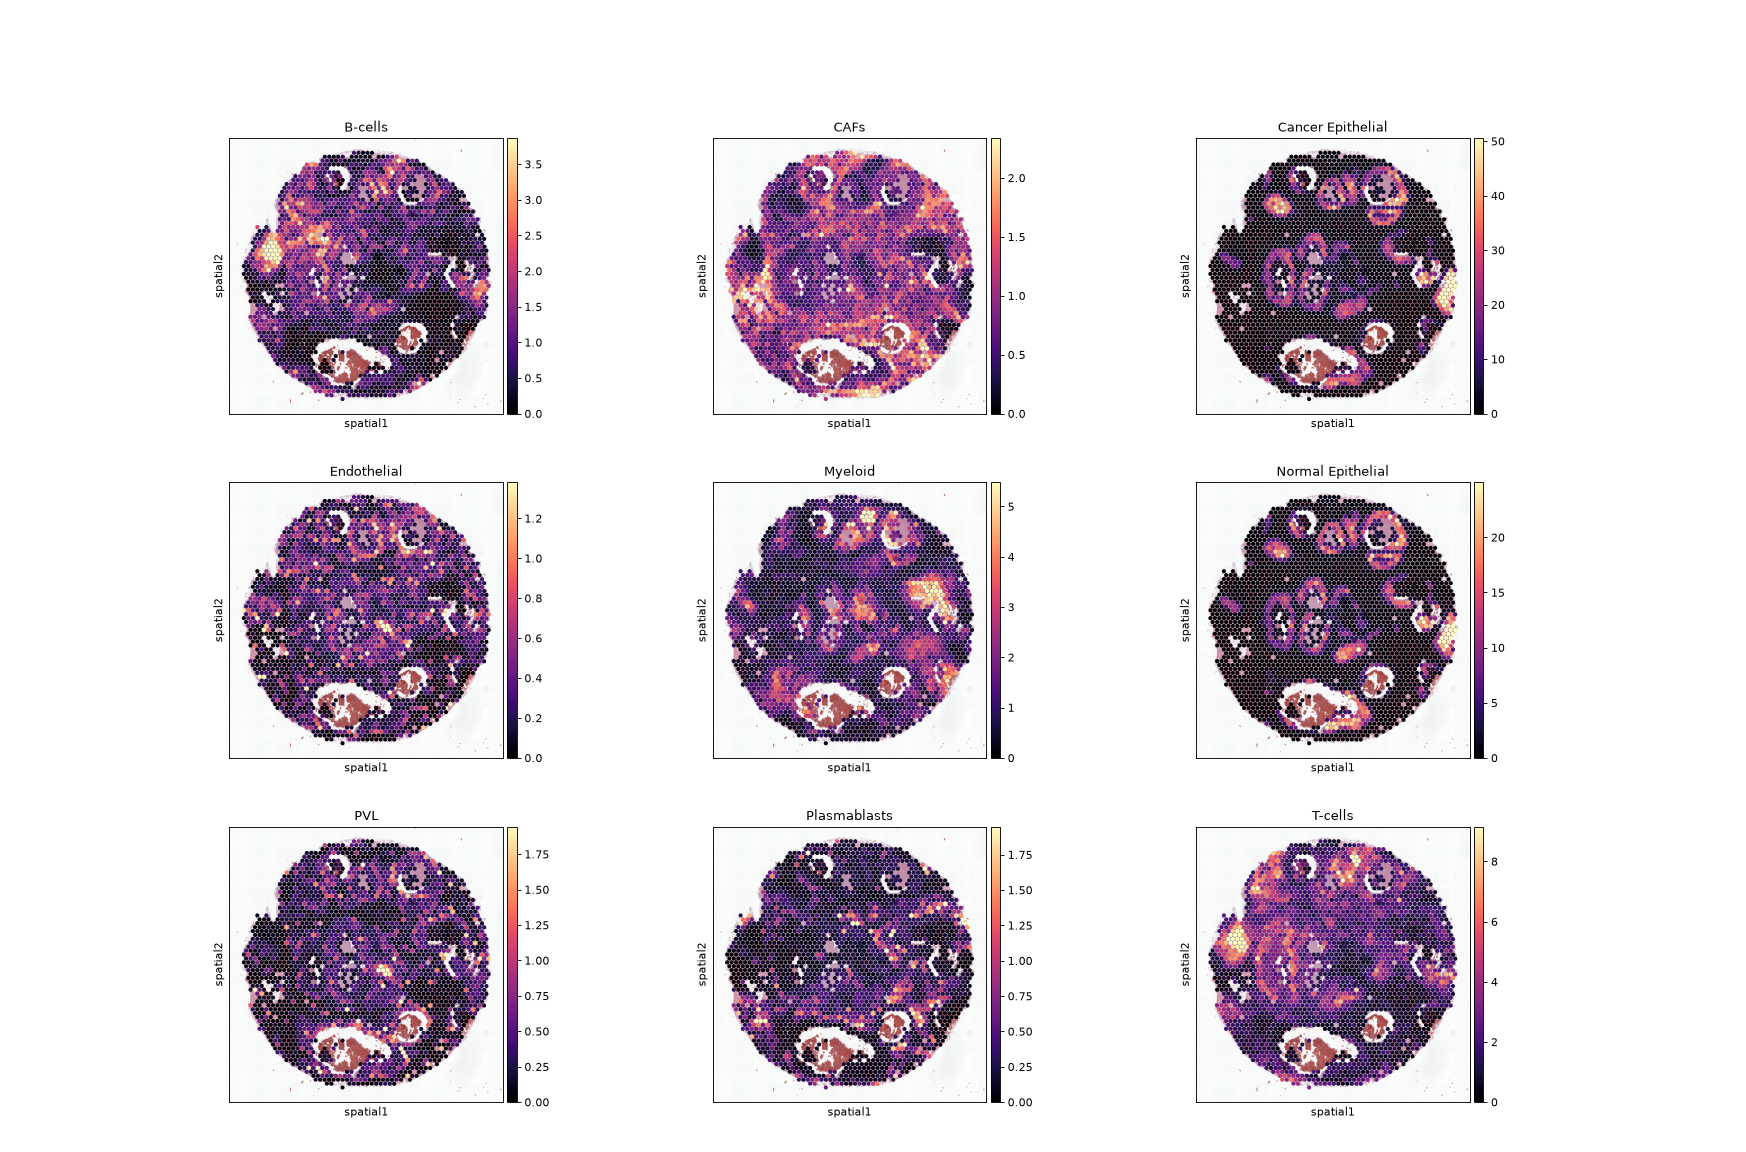

In [99]:
celltype_cols = q05.columns.tolist()
sc.pl.spatial(
    adata_vis,
    color=celltype_cols,
    ncols=3,
    cmap="magma",
    size=1.4,
    vmin=0,
    vmax="p99.2",  # 극단적 outlier spot 때문에 컬러스케일이 눌리는 것을 방지
)

## 7. Deconvolution 결과와 Leiden 공간 도메인 교차 검증

`visium_analysis.ipynb`에서 얻은 leiden 클러스터(공간 도메인, 다세포 혼합 영역)와
이번 deconvolution 결과(스팟별 9종 세포유형 연속값 조성)를 서로 대조한다. 두 결과가
서로 독립적으로 계산됐음에도(leiden은 HVG 발현 패턴 기반 클러스터링, deconvolution은
참조 시그니처 기반 회귀) 일관된 그림을 보이는지 확인하는 것이 목적이다.

In [1]:
# 재로딩 없이 이어서 사용 가능하지만, 이 섹션만 독립적으로 재실행할 수 있도록
# 저장된 체크포인트에서 다시 불러온다 (leiden, 9종 abundance 모두 obs에 저장돼 있음).
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

DECONV_CHECKPOINT = "/data2/projects/2025_heartfailure/spatial_tme/visium_breast/adata_visium_deconvolved.h5ad"
adata_vis = sc.read_h5ad(DECONV_CHECKPOINT)

celltype_cols = adata_vis.obsm["q05_cell_abundance_w_sf"].columns.tolist()
print(celltype_cols)

['B-cells', 'CAFs', 'Cancer Epithelial', 'Endothelial', 'Myeloid', 'Normal Epithelial', 'PVL', 'Plasmablasts', 'T-cells']


In [2]:
# leiden 도메인별 9종 세포유형 abundance(q05) 평균
domain_composition = adata_vis.obs.groupby("leiden", observed=True)[celltype_cols].mean()
domain_composition

,B-cells,CAFs,Cancer Epithelial,Endothelial,Myeloid,Normal Epithelial,PVL,Plasmablasts,T-cells
leiden,,,,,,,,,
0,0.546129,0.495823,15.969995,0.185930,1.557046,11.485687,0.398323,0.095449,1.266420
1,1.823212,0.674264,0.578005,0.295405,0.786516,0.192753,0.203817,0.314448,4.550296
2,0.524001,1.514223,1.428106,0.316009,0.550219,0.636077,0.410874,0.358551,1.640112
3,0.335585,1.592277,0.200542,0.229945,0.884595,0.031773,0.139130,0.067376,1.018186
4,0.666518,1.119873,0.315197,0.159941,0.771660,0.091978,0.137215,0.651839,1.725388
5,0.147959,0.949529,0.297205,0.138164,1.973427,0.078473,0.140028,0.517559,0.953518
6,0.696809,1.164190,0.934780,0.228231,0.776173,0.410437,0.207427,0.537317,1.983351
7,0.486882,0.745199,0.445568,0.769234,0.564156,0.161941,0.775995,0.256798,1.486163
8,1.362355,0.417986,33.869904,0.276390,1.263700,14.921182,0.383777,0.179080,3.037954


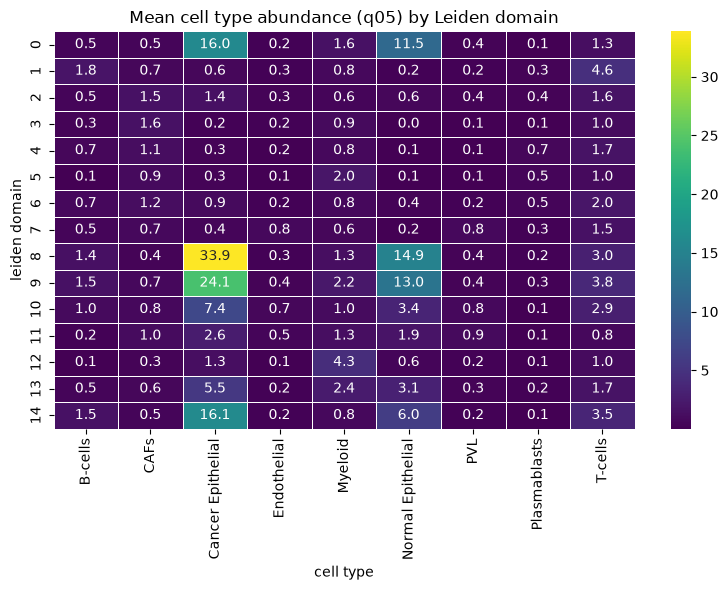

In [3]:
# 도메인(행) x 세포유형(열) 히트맵 — 어떤 도메인이 어떤 세포유형 위주로 구성되는지 한눈에 확인
plt.figure(figsize=(8, 6))
sns.heatmap(domain_composition, cmap="viridis", annot=True, fmt=".1f", linewidths=0.5)
plt.title("Mean cell type abundance (q05) by Leiden domain")
plt.xlabel("cell type")
plt.ylabel("leiden domain")
plt.tight_layout()
plt.show()

In [4]:
# 각 도메인에서 abundance가 가장 높은(우세한) 세포유형 요약
dominant_celltype = domain_composition.idxmax(axis=1)
for domain, celltype in dominant_celltype.items():
    n_spots = (adata_vis.obs["leiden"] == domain).sum()
    print(f"도메인 {domain} (n={n_spots}): {celltype} 우세 (abundance={domain_composition.loc[domain, celltype]:.2f})")

도메인 0 (n=99): Cancer Epithelial 우세 (abundance=15.97)
도메인 1 (n=333): T-cells 우세 (abundance=4.55)
도메인 2 (n=200): T-cells 우세 (abundance=1.64)
도메인 3 (n=76): CAFs 우세 (abundance=1.59)
도메인 4 (n=170): T-cells 우세 (abundance=1.73)
도메인 5 (n=231): Myeloid 우세 (abundance=1.97)
도메인 6 (n=303): T-cells 우세 (abundance=1.98)
도메인 7 (n=77): T-cells 우세 (abundance=1.49)
도메인 8 (n=113): Cancer Epithelial 우세 (abundance=33.87)
도메인 9 (n=216): Cancer Epithelial 우세 (abundance=24.07)
도메인 10 (n=159): Cancer Epithelial 우세 (abundance=7.43)
도메인 11 (n=118): Cancer Epithelial 우세 (abundance=2.63)
도메인 12 (n=84): Myeloid 우세 (abundance=4.30)
도메인 13 (n=135): Cancer Epithelial 우세 (abundance=5.55)
도메인 14 (n=74): Cancer Epithelial 우세 (abundance=16.09)


### Cancer Epithelial 우세 도메인과 공간적 일치 확인

위 표에서 Cancer Epithelial abundance가 가장 높은 도메인을 찾아, 그 도메인에 속한
스팟들의 공간적 위치가 실제 Cancer Epithelial abundance(연속값)가 높은 영역과
겹치는지 육안으로 비교한다.

In [5]:
# Cancer Epithelial abundance가 가장 높은 도메인 식별
tumor_domain = domain_composition["Cancer Epithelial"].idxmax()
print(f"Cancer Epithelial 우세 도메인: {tumor_domain} "
      f"(평균 abundance={domain_composition.loc[tumor_domain, 'Cancer Epithelial']:.2f})")

adata_vis.obs["is_tumor_domain"] = np.where(
    adata_vis.obs["leiden"] == tumor_domain, f"domain {tumor_domain}", "other"
)

Cancer Epithelial 우세 도메인: 8 (평균 abundance=33.87)


/tmp/ipykernel_3456676/510816559.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


/tmp/ipykernel_3456676/510816559.py:14: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


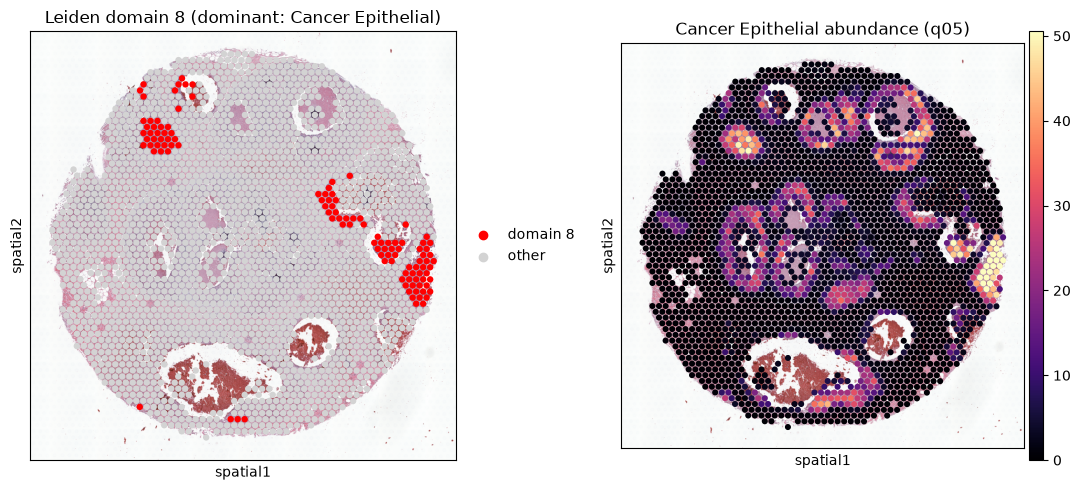

In [6]:
# 왼쪽: Cancer Epithelial 우세 도메인만 강조(나머지는 회색) / 오른쪽: Cancer Epithelial abundance 연속값
# 두 그림의 밝은/강조 영역이 공간적으로 겹치는지가 확인 포인트
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

sc.pl.spatial(
    adata_vis,
    color="is_tumor_domain",
    palette={f"domain {tumor_domain}": "red", "other": "lightgrey"},
    size=1.4,
    ax=axes[0],
    show=False,
    title=f"Leiden domain {tumor_domain} (dominant: Cancer Epithelial)",
)
sc.pl.spatial(
    adata_vis,
    color="Cancer Epithelial",
    cmap="magma",
    size=1.4,
    vmin=0,
    vmax="p99.2",
    ax=axes[1],
    show=False,
    title="Cancer Epithelial abundance (q05)",
)
plt.tight_layout()
plt.show()

### 병리학자 주석 대조

`Visium_FFPE_Human_Breast_Cancer_Pathologist_Annotations.png`(10x 제공 공식 병리 주석,
Fat/Fibrous Tissue/Immune Cells/Invasive Carcinoma/Necrosis 5개 카테고리 윤곽선)를
받아 대조한다.

**주의**: 이 주석 이미지는 Space Ranger의 `tissue_hires_image.png`와 별도로 배포된
이미지라, 두 이미지 사이의 정확한 픽셀 대 픽셀 scale factor가 제공되지 않는다. 프레임
(fiducial dot 테두리)과 조직 윤곽 형태를 육안으로 비교해보면 크롭/해상도는 거의
동일해 보이지만, 정밀한 좌표 정합(image registration)까지는 하지 않았다. 따라서
아래 비교는 스팟 좌표를 주석 이미지에 직접 overlay하는 정량적 방식이 아니라,
**두 그림을 나란히 놓고 병변의 위치가 대략 일치하는지 육안으로 확인하는 정성적 비교**다.
가장 직접적으로 대응되는 카테고리는 병리 주석의 **Invasive Carcinoma**(초록)와
deconvolution의 **Cancer Epithelial** abundance다.

/tmp/ipykernel_3456676/3329417113.py:16: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


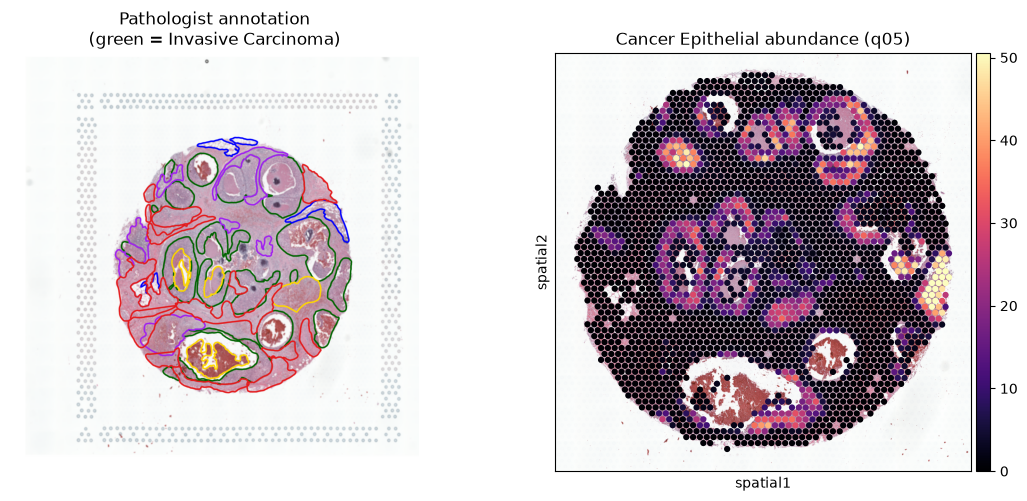

In [7]:
from PIL import Image
import numpy as np

ANNOTATION_PATH = "/data2/projects/2025_heartfailure/spatial_tme/visium_breast/Visium_FFPE_Human_Breast_Cancer_Pathologist_Annotations.png"

# 원본 이미지 오른쪽의 범례(legend) 영역을 제외하고 조직/프레임 부분만 crop
annotation_img = Image.open(ANNOTATION_PATH).crop((0, 0, 2350, 2400))
annotation_img = np.asarray(annotation_img)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].imshow(annotation_img)
axes[0].set_title("Pathologist annotation\n(green = Invasive Carcinoma)")
axes[0].axis("off")

sc.pl.spatial(
    adata_vis,
    color="Cancer Epithelial",
    cmap="magma",
    size=1.4,
    vmin=0,
    vmax="p99.2",
    ax=axes[1],
    show=False,
    title="Cancer Epithelial abundance (q05)",
)
plt.tight_layout()
plt.show()

**관찰**: 병리학자가 Invasive Carcinoma(초록)로 표시한 영역은 대부분 조직 내 duct/gland형
링 구조를 둘러싸고 있는데, deconvolution의 Cancer Epithelial abundance가 높은 스팟들도
같은 링 구조 주변에 집중되는 것을 육안으로 확인할 수 있다 (예: 우측 중앙의 넓은 고발현
영역과 그 위치의 넓은 초록 윤곽선). 다만 두 결과가 완전히 겹치지는 않는데, 병리 주석의
Invasive Carcinoma 경계는 비교적 넓고 연속적인 조직 영역(형태학적 판단) 기준인 반면,
Cancer Epithelial abundance는 스팟 단위 세포 조성 추정치라 같은 Invasive Carcinoma
영역 안에서도 기질/면역세포가 많이 섞인 스팟은 상대적으로 낮게 나온다 — 두 방법이 측정
하는 대상(조직 형태 vs 스팟별 세포 조성)이 다르다는 점을 고려하면 합리적인 차이다.

## 8. Ligand-Receptor Interaction (Leiden 공간 도메인 기준)

Xenium은 single-cell resolution이라 `cell_type`(세포 유형) 간 리간드-수용체(LR)
상호작용을 직접 볼 수 있었다. Visium은 spot이 다세포 혼합이라 세포 유형 단위 LR을
직접 계산할 수 없으므로, 대신 **leiden 공간 도메인**을 그룹으로 사용해 도메인 간 LR을
본다. 도메인은 세포 유형이 아니라 "특정 세포 조성이 우세한 조직 영역"이므로, 결과를
해석할 때는 7장에서 계산한 `domain_composition`(도메인별 우세 세포유형)을 함께 참고해서
"이 신호가 실제로 어떤 세포 구성 간 신호로 보이는지"를 유추해야 한다.

In [2]:
# sq.gr.ligrec은 log1p 정규화된 발현값을 기대하는데, adata_visium_deconvolved.h5ad의
# X는 cell2location 입력을 위해 raw count로 덮어써둔 상태라 그대로 쓰면 안 된다.
# 발현값(X)은 log1p 정규화가 유지된 clustered 체크포인트에서 가져오고,
# 9종 세포유형 abundance는 deconvolved 체크포인트의 obs에서 spot 순서를 맞춰 병합한다.
adata = sc.read_h5ad("/data2/projects/2025_heartfailure/spatial_tme/visium_breast/adata_visium_clustered.h5ad")
deconv_obs = sc.read_h5ad(
    "/data2/projects/2025_heartfailure/spatial_tme/visium_breast/adata_visium_deconvolved.h5ad"
).obs

celltype_cols = ["B-cells", "CAFs", "Cancer Epithelial", "Endothelial", "Myeloid",
                  "Normal Epithelial", "PVL", "Plasmablasts", "T-cells"]
assert (adata.obs_names == deconv_obs.index).all(), "두 체크포인트의 spot 순서가 다름"
adata.obs[celltype_cols] = deconv_obs[celltype_cols]

print(adata)
print("X max (log1p 정규화 유지 확인):", adata.X.max())

AnnData object with n_obs × n_vars = 2388 × 17943
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'n_genes', 'leiden', 'B-cells', 'CAFs', 'Cancer Epithelial', 'Endothelial', 'Myeloid', 'Normal Epithelial', 'PVL', 'Plasmablasts', 'T-cells'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'
X max (log1p 정규화 유지 확인): 8.079207


In [3]:
# Section 7과 동일한 방식으로 도메인별 우세 세포유형 조성 재계산 (LR 해석 근거로 사용)
domain_composition = adata.obs.groupby("leiden", observed=True)[celltype_cols].mean()
dominant_celltype = domain_composition.idxmax(axis=1)
dominant_celltype

leiden
0     Cancer Epithelial
1               T-cells
2               T-cells
3                  CAFs
4               T-cells
5               Myeloid
6               T-cells
7               T-cells
8     Cancer Epithelial
9     Cancer Epithelial
10    Cancer Epithelial
11    Cancer Epithelial
12              Myeloid
13    Cancer Epithelial
14    Cancer Epithelial
dtype: object

### 분석 대상 도메인 쌍

Cancer Epithelial 우세 도메인(8, 9, 14 — 7장 조성 히트맵 기준 abundance가 가장 높은
세 도메인)과, 서로 다른 우세 조성을 대표하는 그 외 도메인들 사이의 양방향 상호작용을 본다:
- T-cells 우세: 도메인 1, 6 (가장 spot 수가 많은 두 T-cell 우세 도메인)
- Myeloid 우세: 도메인 5, 12
- CAFs 우세: 도메인 3

Xenium 노트북과 동일하게, 전체 15x15 도메인 조합이 아니라 관심 있는 (sender, receiver)
방향쌍만 명시적으로 지정해 계산량을 줄인다.

In [4]:
TUMOR_DOMAINS = ["8", "9", "14"]
OTHER_DOMAINS = ["1", "6", "5", "12", "3"]

# 종양 도메인 -> 그 외 도메인, 그 외 도메인 -> 종양 도메인 양방향 모두 포함
LR_CLUSTER_PAIRS = (
    [(t, o) for t in TUMOR_DOMAINS for o in OTHER_DOMAINS]
    + [(o, t) for t in TUMOR_DOMAINS for o in OTHER_DOMAINS]
)
print(f"분석할 방향쌍 수: {len(LR_CLUSTER_PAIRS)}")

분석할 방향쌍 수: 30


In [5]:
# sq.gr.ligrec: CellPhoneDB 방식 permutation test.
# interactions_params={"resources": "CellPhoneDB"}로 후보 리간드-수용체 쌍을 CellPhoneDB
# 큐레이션 목록(약 1,600쌍)으로 제한한다. 기본값(omnipath+pathwayextra+kinaseextra+
# ligrecextra 통합 리소스)을 그대로 쓰면 whole transcriptome(17,943개 유전자) 대부분이
# 후보가 되어 30개 방향쌍 x 수만 개 LR 조합이 테스트되고, 그중 수만 개가 "유의"하게 나와
# (Xenium은 377개 타깃 패널이라 애초에 후보가 적었던 것과 대조적) 결과를 해석할 수 없는
# 지경이 된다. CellPhoneDB 리소스로 좁히면 후보가 관리 가능한 수준(1,600여 쌍)이 된다.
# use_raw=False로 log1p 정규화된 adata.X를 사용한다.
# 예상 소요 시간: 30개 방향쌍, n_perms=1000, CellPhoneDB 리소스 기준 — 실측 약 20초 내외.
sq.gr.ligrec(
    adata,
    cluster_key="leiden",
    clusters=LR_CLUSTER_PAIRS,
    use_raw=False,
    n_perms=1000,
    seed=0,
    interactions_params={"resources": "CellPhoneDB"},
)

/data1/home/woodg/miniconda3/envs/spatial/lib/python3.11/site-packages/squidpy/gr/_ligrec.py:399: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["clusters"] = data["clusters"].cat.remove_unused_categories()
/data1/home/woodg/miniconda3/envs/spatial/lib/python3.11/site-packages/squidpy/gr/_ligrec.py:408: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["clusters"] = cat.rename_categories(cluster_mapper)


  0%|          | 0/1000 [00:00<?, ?permutation/s]

In [6]:
# 유의한 LR 쌍을 (ligand, receptor, sender domain, receiver domain, mean_expr, pvalue)
# 표로 정리
result = adata.uns["leiden_ligrec"]
means, pvalues = result["means"], result["pvalues"]

mean_long = means.stack(level=[0, 1], future_stack=True).rename("mean_expr")
pval_long = pvalues.stack(level=[0, 1], future_stack=True).rename("pvalue")
lr_table = pd.concat([mean_long, pval_long], axis=1).reset_index()
lr_table.columns = ["ligand", "receptor", "sender", "receiver", "mean_expr", "pvalue"]

print(f"유의한(p<0.05) LR 쌍 수: {(lr_table['pvalue'] < 0.05).sum()} / {len(lr_table)}")

유의한(p<0.05) LR 쌍 수: 6450 / 49170


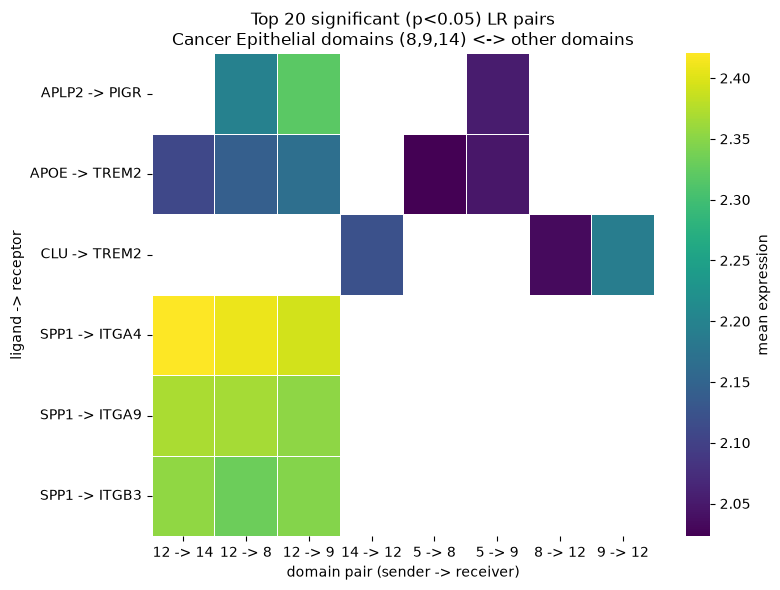

In [7]:
# sq.pl.ligrec 기본 시각화는 "유의하지 않은 쌍 제거" 옵션을 켜도 테스트된 리간드-수용체
# 후보 전체(1,600여 쌍)를 행으로 다 그려서 실질적으로 읽을 수 없다. 대신 유의한(p<0.05)
# 쌍 중 mean_expr 상위 N개만 뽑아 직접 히트맵을 그린다.
N_TOP_LR = 20
top_lr = (
    lr_table[lr_table["pvalue"] < 0.05]
    .sort_values("mean_expr", ascending=False)
    .head(N_TOP_LR)
    .copy()
)
top_lr["lr_pair"] = top_lr["ligand"] + " -> " + top_lr["receptor"]
top_lr["domain_pair"] = top_lr["sender"] + " -> " + top_lr["receiver"]

heatmap_data = top_lr.pivot_table(index="lr_pair", columns="domain_pair", values="mean_expr")
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, cmap="viridis", linewidths=0.5, cbar_kws={"label": "mean expression"})
plt.title(f"Top {N_TOP_LR} significant (p<0.05) LR pairs\nCancer Epithelial domains (8,9,14) <-> other domains")
plt.xlabel("domain pair (sender -> receiver)")
plt.ylabel("ligand -> receptor")
plt.tight_layout()
plt.show()

In [8]:
# 각 LR 쌍의 sender/receiver 도메인이 어떤 세포유형 우세 영역인지 병기 —
# "도메인 8(Cancer Epithelial 우세) -> 도메인 1(T-cells 우세)" 형태로 바로 해석 가능하게
top_lr["sender_dominant_celltype"] = top_lr["sender"].map(dominant_celltype)
top_lr["receiver_dominant_celltype"] = top_lr["receiver"].map(dominant_celltype)
top_lr[["ligand", "receptor", "sender", "sender_dominant_celltype",
        "receiver", "receiver_dominant_celltype", "mean_expr", "pvalue"]]

,ligand,receptor,sender,sender_dominant_celltype,receiver,receiver_dominant_celltype,mean_expr,pvalue
16563,SPP1,ITGA4,12,Myeloid,14,Cancer Epithelial,2.420365,0.0
16564,SPP1,ITGA4,12,Myeloid,8,Cancer Epithelial,2.409086,0.0
16565,SPP1,ITGA4,12,Myeloid,9,Cancer Epithelial,2.393023,0.0
9723,SPP1,ITGA9,12,Myeloid,14,Cancer Epithelial,2.370138,0.0
9724,SPP1,ITGA9,12,Myeloid,8,Cancer Epithelial,2.36604,0.0
12303,SPP1,ITGB3,12,Myeloid,14,Cancer Epithelial,2.353842,0.0
9725,SPP1,ITGA9,12,Myeloid,9,Cancer Epithelial,2.352646,0.0
12305,SPP1,ITGB3,12,Myeloid,9,Cancer Epithelial,2.345976,0.0
12304,SPP1,ITGB3,12,Myeloid,8,Cancer Epithelial,2.331444,0.0
25535,APLP2,PIGR,12,Myeloid,9,Cancer Epithelial,2.318925,0.0


### Xenium LR vs Visium LR — 방법론적 차이

| | Xenium | Visium |
|---|---|---|
| 분석 단위 | 개별 세포 (single-cell resolution) | spot (55µm, 다세포 혼합) |
| 그룹 기준 | `cell_type` (세포 유형 직접) | `leiden` 공간 도메인 (조성이 비슷한 영역) |
| 신호 해석 | "세포 유형 A가 세포 유형 B에 보내는 신호"로 직접 해석 가능 | "도메인 A가 도메인 B에 보내는 신호" — 실제로는 그 도메인에 섞여 있는 여러 세포 유형의 평균 발현이 뒤섞인 결과이므로, 특정 세포 유형 쌍 간 신호라고 단정할 수 없음 |
| 보강 방법 | 불필요 (이미 세포 단위) | 도메인별 우세 조성(`domain_composition`)을 함께 제시해 "이 도메인은 Cancer Epithelial이 우세하다"는 정황 근거로 해석을 보강 |
| 한계 | 상대적으로 적은 유전자 패널(377개)이라 리간드/수용체가 패널에 없으면 아예 검출 불가 | whole transcriptome이라 패널 제약은 없지만, spot 내 세포 조성이 도메인마다 균일하지 않아 신호의 출처(sender/receiver)가 다세포 평균에 의해 흐려짐(신호 희석) |

즉 Visium LR 결과는 "이 조직 영역과 저 조직 영역 사이에 이런 리간드-수용체 신호가
유의하게 관찰된다"는 정황적 증거이지, Xenium처럼 "이 세포 유형이 저 세포 유형에게
신호를 보낸다"는 직접적 증거는 아니다.

## 9. 최종 체크포인트 저장

log1p 정규화 발현값, leiden 공간 도메인, 9종 세포유형 조성(obs), LR 분석 결과
(`uns["leiden_ligrec"]`)까지 모두 반영된 상태를 하나의 파일로 저장해, 이후 분석에서
다시 계산하지 않고 바로 불러올 수 있게 한다.

In [9]:
# adata.uns["leiden_ligrec"]["means"/"pvalues"]는 MultiIndex 컬럼(도메인 쌍)을 가진
# DataFrame인데, h5ad(HDF5)는 MultiIndex/튜플 컬럼명을 직렬화하지 못해 그대로 저장하면
# 에러가 난다. 이미 계산해둔 평평한(flat) lr_table로 대체해서 저장한다.
# mean_expr 컬럼은 squidpy가 SparseArray로 반환하는데 이 역시 h5ad에 직접 쓸 수 없어
# 일반 float로 밀도화(densify)한다.
lr_table_flat = lr_table.astype({"mean_expr": float, "pvalue": float})
adata.uns["leiden_ligrec_table"] = lr_table_flat
del adata.uns["leiden_ligrec"]

FINAL_CHECKPOINT = "/data2/projects/2025_heartfailure/spatial_tme/visium_breast/adata_visium_final.h5ad"
adata.write(FINAL_CHECKPOINT)
print(f"저장 완료: {FINAL_CHECKPOINT}")

저장 완료: /data2/projects/2025_heartfailure/spatial_tme/visium_breast/adata_visium_final.h5ad
